# **Testing a New Recommendation Algorythm in a Music Streaming App**
---



* A music streaming app introduces a new recommendation system.The company wants to know whether the new algorythm improves user engagement.

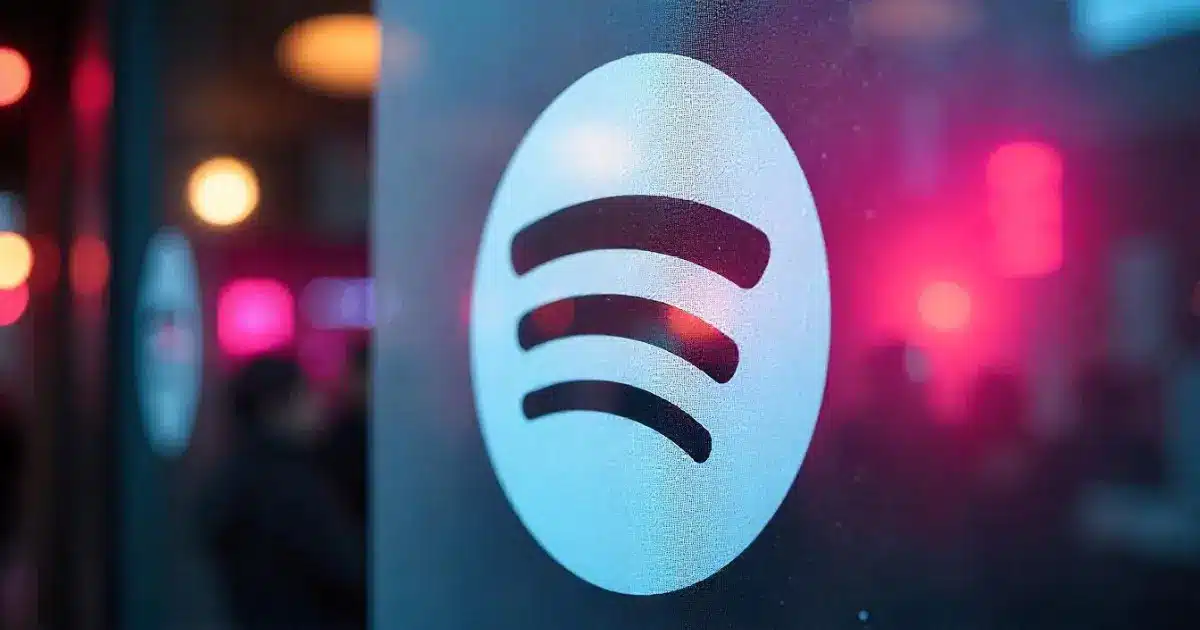

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


np.random.seed(42)

n = 2000

groups = np.random.choice(
    ['control', 'treatment'],
    size=n
)

session_minutes = np.where(
    groups == 'control',
    np.random.normal(20, 5, n),
    np.random.normal(25, 5, n)
)

songs_played = np.where(
    groups == 'control',
    np.random.normal(8, 2, n),
    np.random.normal(11, 2, n)
)

skips = np.where(
    groups == 'control',
    np.random.normal(5, 1.5, n),
    np.random.normal(3, 1.5, n)
)

retained = np.where(
    groups == 'control',
    np.random.binomial(1, 0.45, n),
    np.random.binomial(1, 0.58, n)
)

df = pd.DataFrame({
    'user_id': range(1, n + 1),
    'group': groups,
    'session_minutes': session_minutes,
    'songs_played': songs_played,
    'skips': skips,
    'retained': retained
})

df.to_csv('music_app_ab_test.csv', index=False)

df.head()

,user_id,group,session_minutes,songs_played,skips,retained
0,1,control,20.888505,8.558168,3.897993,0
1,2,treatment,21.751174,11.017577,0.553399,1
2,3,control,21.900989,4.618657,6.775324,0
3,4,control,23.052929,6.043001,3.253005,1
4,5,control,22.798952,13.510435,3.194130,1


* The synthetic data was designed to mimic a real product experiment by randomly assigning users into control and treatment groups while simulating realistic engagement metrics such as session duration,skips and retention.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2000 non-null   int64  
 1   group            2000 non-null   object 
 2   session_minutes  2000 non-null   float64
 3   songs_played     2000 non-null   float64
 4   skips            2000 non-null   float64
 5   retained         2000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 93.9+ KB


In [ ]:
df.shape

(2000, 6)

# **Data Cleaning**

---



In [ ]:
df.isnull().sum()


,0
user_id,0
group,0
session_minutes,0
songs_played,0
skips,0
retained,0


In [ ]:
df.duplicated().sum()

np.int64(0)

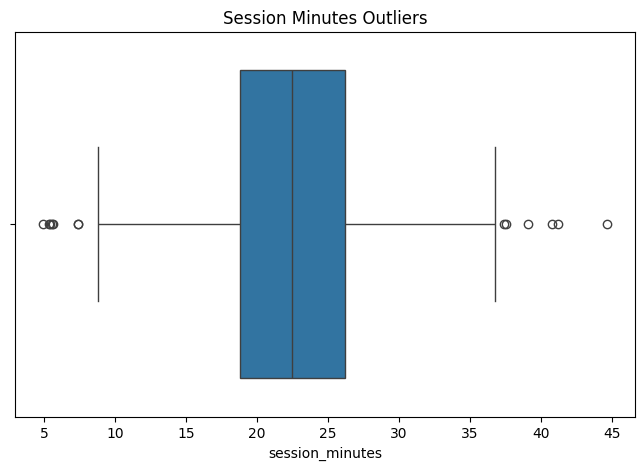

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['session_minutes'])

plt.title("Session Minutes Outliers")
plt.show()

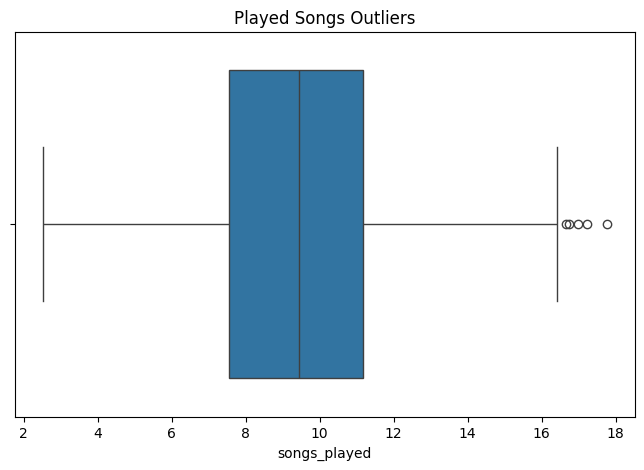

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['songs_played'])

plt.title("Played Songs Outliers")
plt.show()

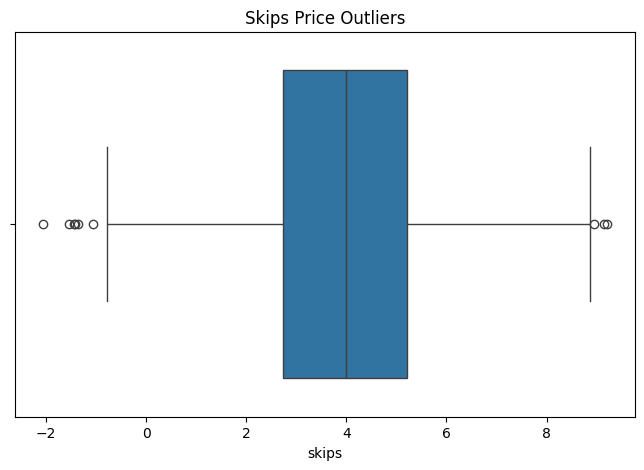

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['skips'])

plt.title("Skips Price Outliers")
plt.show()

### Interpretation of Outlier Box Plots

An outlier is typically defined as a data point that falls outside of 1.5 times the interquartile range (IQR) from the first or third quartile.



*   **Session Minutes Outliers:**
    *   The box plot for `session_minutes` shows the distribution of the duration users spend in their sessions. While the data is largely concentrated around the median, there are some individual points (represented by dots beyond the 'whiskers') that fall outside the typical range. These indicate sessions that are either unusually short or unusually long compared to the majority of users.

*   **Played Songs Outliers:**
    *   The box plot for `songs_played` illustrates the distribution of the number of songs users play in a session. Similar to `session_minutes`, there are data points identified as outliers. These outliers suggest users who either play significantly fewer or significantly more songs than the average user during a session.

*   **Skips Outliers:**
    *   The box plot for `skips` displays the distribution of the number of songs skipped by users. Here, we can also observe several outliers. These outliers represent users who skip a notably higher or lower number of songs than what is typical. For instance, some users might skip very few songs, indicating higher satisfaction or less exploration, while others might skip many, suggesting dissatisfaction or active search for new music.

**General Observation:**

Given that this is simulated A/B test data, these 'outliers' might not necessarily represent data entry errors. Instead, they could indicate the natural variability in user behavior within the music streaming app. For example, some users naturally have very different listening habits. It's important to keep these distributions in mind when analyzing the overall impact of the new recommendation algorithm, as changes in the frequency or distribution of these 'outliers' between the control and treatment groups could be significant.

# **Exploratory Data Analysis(EDA)**

---



In [ ]:
# Group Distribution

df['group'].value_counts()

,count
group,
control,1016
treatment,984


In [ ]:
# Compare group means

df.groupby('group').mean(numeric_only=True)

,user_id,session_minutes,songs_played,skips,retained
group,,,,,
control,1018.467520,20.190220,7.925199,4.953539,0.454724
treatment,981.948171,24.882458,10.974866,2.978540,0.559959


* The treatment group performed better across all engagement metrics,indicating that the new recommendation system may improve user experinece and retention.

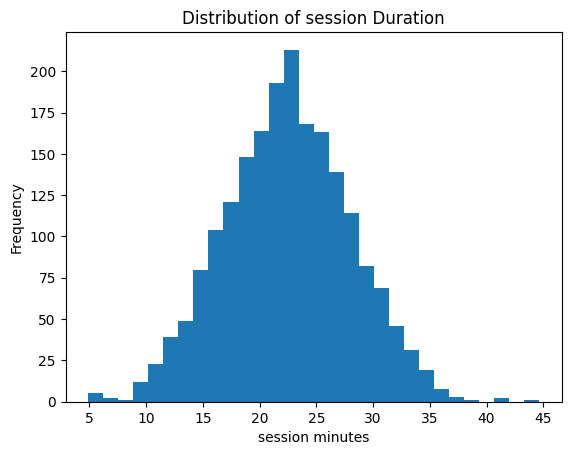

In [ ]:
# Session duration distribution

plt.hist(df['session_minutes'],bins=30)

plt.xlabel('session minutes')
plt.ylabel('Frequency')
plt.title('Distribution of session Duration')

plt.show()

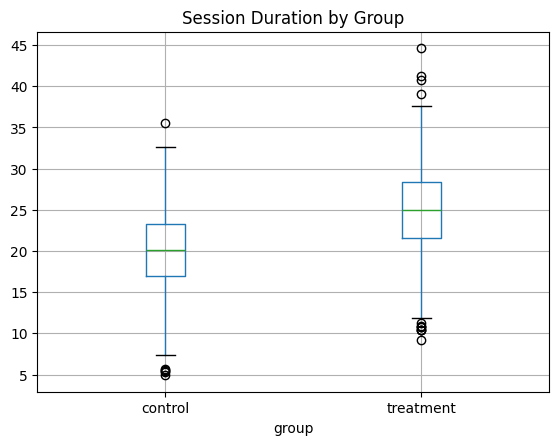

In [ ]:
# Boxplot by Group

df.boxplot(column='session_minutes',by='group')

plt.title('Session Duration by Group')
plt.suptitle('')

plt.show()

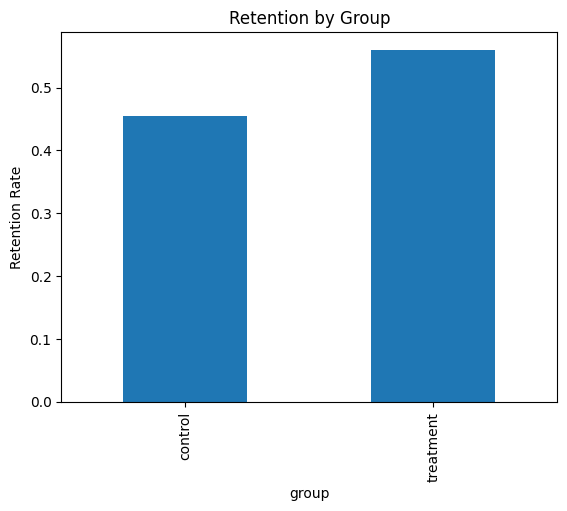

In [ ]:
# Retention Rate Comparison

retention = df.groupby('group')['retained'].mean()

retention.plot(kind='bar')
plt.ylabel('Retention Rate')
plt.title('Retention by Group')
plt.show()

In [ ]:
# Correlation Analysis

corr= df.corr(numeric_only=True)

corr

,user_id,session_minutes,songs_played,skips,retained
user_id,1.000000,-0.010743,-0.001804,0.031012,-0.025282
session_minutes,-0.010743,1.000000,0.262374,-0.263988,0.066306
songs_played,-0.001804,0.262374,1.000000,-0.338378,0.026395
skips,0.031012,-0.263988,-0.338378,1.000000,-0.044198
retained,-0.025282,0.066306,0.026395,-0.044198,1.000000


### Interpretation of Correlation Analysis

The correlation matrix shows the linear relationship between numerical variables in the dataset. Values range from -1 to 1:
*   **1** indicates a perfect positive linear relationship.
*   **-1** indicates a perfect negative linear relationship.
*   **0** indicates no linear relationship.

Let's interpret the correlations:

*   **`session_minutes` and `songs_played` (0.262374):** There is a moderate positive correlation. This means that as the duration of a session increases, the number of songs played also tends to increase. This is intuitive, as longer sessions naturally allow for more songs to be played.

*   **`session_minutes` and `skips` (-0.263988):** There is a moderate negative correlation. As session minutes increase, the number of skips tends to decrease. This might suggest that users who are more engaged (longer sessions) tend to skip fewer songs, perhaps because they are finding more content they enjoy, or they are less likely to leave a session due to disliking a song.

*   **`songs_played` and `skips` (-0.338378):** There is a stronger negative correlation here. As the number of songs played increases, the number of skips tends to decrease. This could indicate that users who play more songs are either finding more relevant content or are more tolerant of a wider range of music, leading to fewer skips.

*   **`retained` with other variables:**
    *   `retained` and `session_minutes` (0.066306): A small positive correlation. Users with slightly longer sessions are marginally more likely to be retained.
    *   `retained` and `songs_played` (0.026395): A very small positive correlation. Playing more songs has a negligible positive association with retention.
    *   `retained` and `skips` (-0.044198): A very small negative correlation. Fewer skips are negligibly associated with higher retention.

*   **`user_id`:** As expected, `user_id` has almost no correlation with any other variable, as it is just an identifier.

**Overall:**

The correlations make intuitive sense: longer sessions are associated with more songs played and fewer skips. Retention shows very weak correlations with individual engagement metrics, suggesting that while these metrics might contribute to retention, they are not strong standalone predictors in this simulated dataset.

# **Hypothesis Testing**

---



In [ ]:
# Separate the groups

control = df[df['group'] == 'control'] ['session_minutes']

treatment = df[df['group'] == 'treatment'] ['session_minutes']

In [ ]:
# Run an indipendent t-test

from scipy.stats import ttest_ind

t_stat,p_value = ttest_ind(treatment,control)

print('T-statistic:', t_stat)
print('P-value:',p_value)

T-statistic: 20.989911558070517
P-value: 1.4717257113401897e-88


* The difference in session duration between the control and treatment is statistically significant,suggesting the new recommendation algorythm improved user engaegement.

In [ ]:
# Songs Played

control = df[df['group'] == 'control'] ['songs_played']

treatment = df[df['group'] == 'treatment'] ['songs_played']

t_stat,p_value = ttest_ind(treatment,control)

print('T-statistic:', t_stat)
print('P-value:',p_value)

T-statistic: 32.92818296181689
P-value: 2.464942401283322e-190


### Interpretation of T-statistic and P-value for Songs Played

For the 'songs_played' metric, an independent t-test was performed to compare the means of the control and treatment groups. The results are:

*   **T-statistic: `32.93`**
*   **P-value: `2.46e-190` (a very small number, practically 0)**

Let's break down what these values mean:

*   **T-statistic (32.93):**
    *   The t-statistic measures the size of the difference between the two group means (`treatment` vs. `control`) relative to the variation within the groups. A larger absolute value of the t-statistic indicates a greater difference between the group means compared to the variability within the groups. In this case, `32.93` is a very large positive t-statistic, suggesting that the mean number of songs played in the treatment group is significantly higher than in the control group.

*   **P-value (2.46e-190):**
    *   The p-value tells us the probability of observing a t-statistic as extreme as, or more extreme than, `32.93` (or an equivalent difference in means) if there were *no actual difference* between the true means of the two groups (i.e., if the null hypothesis were true). A commonly used significance level (alpha) is 0.05.
    *   Here, the p-value is extremely small (much, much less than 0.05). This means that it is highly improbable to observe such a large difference in songs played between the two groups by random chance alone, assuming the new recommendation system had no effect.

**Conclusion:**

Given the very large t-statistic and the extremely small p-value, we can **reject the null hypothesis** that there is no difference in the mean number of songs played between the control and treatment groups. This provides strong statistical evidence that the new recommendation system (treatment group) led to a significant increase in the average number of songs played per session compared to the old system (control group). This reinforces the earlier observation that the treatment group performed better across engagement metrics.

In [ ]:
# count retained users

from statsmodels.stats.proportion import proportions_ztest

control_retained = df[df['group'] == 'control']['retained'].sum()

treatment_retained = df[df['group'] == 'treatment']['retained'].sum()

print(control_retained)
print(treatment_retained)

462
551


In [ ]:
# Count total users per group

control_total = df[df['group'] == 'control']['retained'].count()

treatment_total = df[df['group'] == 'treatment']['retained'].count()

print(control_total)
print(treatment_total)

1016
984


In [ ]:
# Run the propotion z-test


successes = [
    treatment_retained,
    control_retained
]

totals = [
    treatment_total,
    control_total
]

z_stat, p_value = proportions_ztest(
    successes,
    totals
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 4.706044834516743
P-value: 2.5256899437635907e-06


* The increase in retention observed in the treatment group is statistically significant and unlikely to have occurred by chance.

* Users exposed to the new recommendation algorithm demonstrated significantly higher retention rates compared to the control group, suggesting the feature improved user engagement and likelihood of returning to the app

##**Retention Confidence Intervals**

---



In [ ]:
# calculate retention rates

control_rate = control_retained / control_total
treatment_rate = treatment_retained / treatment_total

print(control_rate)
print(treatment_rate)

0.4547244094488189
0.5599593495934959


In [ ]:
# Difference in retention
difference = treatment_rate - control_rate

print(difference)

0.10523494014467699


In [ ]:
# Standard Error
import numpy as np

se = np.sqrt(
    (control_rate * (1 - control_rate) / control_total)
    +
    (treatment_rate * (1 - treatment_rate) / treatment_total)
)

print(se)

0.022236385820074603


In [ ]:
# Confidence Interval
lower = difference - 1.96 * se
upper = difference + 1.96 * se

print("95% Confidence Interval:")
print(lower, upper)

95% Confidence Interval:
0.06165162393733077 0.14881825635202323


* We are 95% confident that the new recommendation algorithm improves retention by between 6% and 14%.

##**Effect Size (Cohen’s d)**

---



In [ ]:
 # Cohen’s d for Session Duration

control_sessions = df[
    df['group'] == 'control'
]['session_minutes']
treatment_sessions = df[
    df['group'] == 'treatment'
]['session_minutes']

In [ ]:
# Calculate Cohen’s d

mean_diff = (
    treatment_sessions.mean()
    -
    control_sessions.mean()
)

pooled_std = np.sqrt(
    (
        control_sessions.std()**2
        +
        treatment_sessions.std()**2
    ) / 2
)

cohens_d = mean_diff / pooled_std

print(cohens_d)

0.9382045583657068


* The treatment group experienced substantially higher session durations compared to the control group.

This indicates:

* stronger engagement
* noticeable user behavior change
* meaningful product impact

* Based on the A/B testing analysis, the treatment group consistently outperformed the control group across key engagement metrics including session duration, songs played, skip behavior, and retention rate.

* Statistical testing confirmed that the retention improvement was significant (p<0.05), suggesting that the new recommendation algorithm positively impacted user engagement and return behavior.

* Given the observed improvements, it is recommended that the company deploy the new recommendation algorithm to all users while continuing to monitor long-term retention and user satisfaction metrics.